In [1]:
# Let's add the root directory to our system search path to allow imports from sibling directories.
import os, sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
import gc, random
from pathlib import Path
from typing import List

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF

from sklearn.metrics import classification_report, confusion_matrix

from tqdm.notebook import tqdm

from src.utils import load_backbone, run_inference, show_images

WEIGHTS_DIR = Path("../weights/")
EPOCH_COUNT = len(list(WEIGHTS_DIR.iterdir())) - 2

DEVICE = torch.device("cuda")  # ConvNeXtV2 doesn't support CPU

SEED = 42
RNG = np.random.default_rng(seed=SEED)
random.seed(SEED)

DATASET_PATH = Path("../data/labelled/AI4Shipwrecks")
IMGS_PATH = DATASET_PATH / "images/"
MASK_PATH = DATASET_PATH / "masks/"
EMBEDS_PATH = DATASET_PATH / "embeds/"
DATA_EXT = '.png'

# Few Shot Scalability (1%, 5%, 10%, 50%, 100%)
FEW_SHOT = (0.01, 0.05, 0.10, 0.50, 1.00)

DATA_FILES = sorted([im.stem for im in IMGS_PATH.glob(f"*{DATA_EXT}")])
N = len(DATA_FILES)
TEST_SPLIT = int(0.2 * N)

random.shuffle(DATA_FILES)
TEST_FILES = DATA_FILES[:TEST_SPLIT]
TRAIN_FILES = DATA_FILES[TEST_SPLIT:]

MODEL_PATH = WEIGHTS_DIR / "unet_shipwreck_final.pth"

/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:97: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:163: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:243: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Pl

In [3]:
def print_iou(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Normalize row-wise (True labels) to handle large scale disparities
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm.astype(float),
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0
    )

    print("Confusion Matrix (Normalized):")

    header = f"{'True / Pred':>12} | " + " ".join([f"{str(label):>7}" for label in labels])
    print(header)
    print("-" * len(header))

    # Print each row with normalized values to 3 decimal places
    for i, row_label in enumerate(labels):
        row_str = " ".join([f"{val:>7.3f}" for val in cm_norm[i]])
        print(f"{str(row_label):>12} | {row_str}")

    print("-" * len(header))

    # --- Calculate and Print IoU on raw counts ---
    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection

    iou = np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection, dtype=float),
        where=union != 0
    )

    print("\nIoU per class:")
    for label, val in zip(labels, iou):
        print(f"  Class {str(label):<5}: {val:.3f}")

    print("-" * 20)
    print(f"Mean IoU (mIoU) : {np.mean(iou):.3f}")

In [4]:
class UNetShipwreckDecoder(nn.Module):
    def __init__(self):
        super(UNetShipwreckDecoder, self).__init__()

        # --- Stage: W/32 to W/16 ---
        # Upsample 768 channels -> 384 channels
        self.up_w32 = nn.ConvTranspose2d(768, 384, kernel_size=4, stride=2, padding=1)
        # Concat: 384 (upsampled) + 384 (s_w16) = 768
        self.conv_w16 = nn.Sequential(
            nn.Conv2d(768, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True)
        )

        # --- Stage: W/16 to W/8 ---
        # Upsample 384 channels -> 192 channels
        self.up_w16 = nn.ConvTranspose2d(384, 192, kernel_size=4, stride=2, padding=1)
        # Concat: 192 (upsampled) + 192 (s_w8) = 384
        self.conv_w8 = nn.Sequential(
            nn.Conv2d(384, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True)
        )

        # --- Stage: W/8 to W/4 ---
        # Upsample 192 channels -> 96 channels
        self.up_w8 = nn.ConvTranspose2d(192, 96, kernel_size=4, stride=2, padding=1)
        # Concat: 96 (upsampled) + 96 (s_w4) = 192
        self.conv_w4 = nn.Sequential(
            nn.Conv2d(192, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True)
        )

        # --- Stage: W/4 to Final Mask (Upsample by 4x total) ---
        self.final_up1 = nn.Sequential(
            nn.ConvTranspose2d(96, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.final_up2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, s_w32, s_w16, s_w8, s_w4):
        """
        Expects inputs in order from lowest spatial resolution to highest:
        s_w32: 768c
        s_w16: 384c
        s_w8: 192c
        s_w4: 96c
        """
        # 1. Upsample W/32, match size, concat with W/16
        x = self.up_w32(s_w32)
        x = torch.cat([x, s_w16], dim=1)
        x = self.conv_w16(x)

        # 2. Upsample W/16, match size, concat with W/8
        x = self.up_w16(x)
        x = torch.cat([x, s_w8], dim=1)
        x = self.conv_w8(x)

        # 3. Upsample W/8, match size, concat with W/4
        x = self.up_w8(x)
        x = torch.cat([x, s_w4], dim=1)
        x = self.conv_w4(x)

        # 4. Final 4x upsample to original image size
        x = self.final_up1(x)
        x = self.final_up2(x)

        # 5. Output
        logits = self.classifier(x)
        return logits.squeeze(1)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        """
        Args:
            alpha (float): Weighting factor for the positive class (shipwrecks).
            gamma (float): Focusing parameter. Higher values reduce the loss for well-classified examples.
            reduction (str): 'mean', 'sum', or 'none'.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Calculate standard BCE with logits (no reduction so we can apply the focal weights per-pixel)
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        
        # Get the predicted probabilities
        probs = torch.sigmoid(inputs)
        
        # p_t is the probability of the true class
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Calculate the modulating factor (1 - p_t)^gamma
        modulating_factor = (1.0 - p_t) ** self.gamma
        
        # Calculate the alpha weighting factor
        alpha_factor = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        
        # Combine everything
        focal_loss = alpha_factor * modulating_factor * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, smooth=1.0):
        super(FocalDiceLoss, self).__init__()
        # Initialize your existing Focal Loss with a moderate alpha
        self.focal = FocalLoss(alpha=alpha, gamma=gamma, reduction='mean')
        self.smooth = smooth

    def forward(self, inputs, targets):
        # 1. Calculate Focal Loss
        focal_loss = self.focal(inputs, targets)
        
        # 2. Calculate Dice Loss
        probs = torch.sigmoid(inputs)
        
        # Flatten tensors to 1D to calculate global intersection
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (probs_flat * targets_flat).sum()
        
        # Dice coefficient formula: (2 * Intersection) / (Prediction_Sum + Target_Sum)
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1.0 - dice_score
        
        # Combine both losses
        return focal_loss + dice_loss


class DynamicShipwreckDataset(Dataset):
    def __init__(self, file_list, mask_dir, embeds_dir, data_ext='.png', augment=False):
        self.file_list = file_list
        self.mask_dir = Path(mask_dir)
        self.embeds_dir = Path(embeds_dir)
        self.data_ext = data_ext
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_id = self.file_list[idx]
        mask_path = self.mask_dir / (file_id + self.data_ext)
        embed_path = self.embeds_dir / (file_id + '.npz')

        # Read mask on demand: (H, W)
        mask_np = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED).astype(np.float32)
        mask = torch.from_numpy(mask_np)

        # Load embeddings on demand
        with np.load(embed_path) as data:
            # Map stages: stage3 (W/32), stage2 (W/16), stage1 (W/8), stage0 (W/4)
            # Permute from (H, W, C) -> (C, H, W)
            s1 = torch.from_numpy(data['stage3'].astype(np.float32)).permute(2, 0, 1)
            s2 = torch.from_numpy(data['stage2'].astype(np.float32)).permute(2, 0, 1)
            s3 = torch.from_numpy(data['stage1'].astype(np.float32)).permute(2, 0, 1)
            s4 = torch.from_numpy(data['stage0'].astype(np.float32)).permute(2, 0, 1)

        # Synchronized Data Augmentation (Train only)
        if self.augment:
            if random.random() > 0.5:
                s1 = TF.hflip(s1)
                s2 = TF.hflip(s2)
                s3 = TF.hflip(s3)
                s4 = TF.hflip(s4)
                mask = TF.hflip(mask)

            if random.random() > 0.5:
                s1 = TF.vflip(s1)
                s2 = TF.vflip(s2)
                s3 = TF.vflip(s3)
                s4 = TF.vflip(s4)
                mask = TF.vflip(mask)

        return (s1, s2, s3, s4), mask

In [5]:
EMBEDS_PATH.mkdir(exist_ok=True)

embed_files = list(EMBEDS_PATH.glob('*.npz'))
if len(embed_files) < N:
    model = load_backbone(WEIGHTS_DIR / "checkpoint_latest.pth")

    for file in DATA_FILES:
        embed_path = EMBEDS_PATH / (file + '.npz')
        if embed_path.exists():
            continue

        img_path = IMGS_PATH / (file + DATA_EXT)
        img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED).astype(np.float32)
        img = torch.from_numpy(img[np.newaxis, :, :])  # (W, H) -> (1, W, H)

        cls, flat_patches, outputs = run_inference(model, img)
        np.savez_compressed(
            embed_path,
            cls=cls,
            stage0=outputs[0],
            stage1=outputs[1],
            stage2=outputs[2],
            stage3=outputs[3],
            stage4=outputs[4],  # Fused Hypercolumn
        )

In [6]:
# masks, embeds = None, None
# for i, file in enumerate(tqdm(DATA_FILES)):
#     mask_path = MASK_PATH / (file + DATA_EXT)
#     embed_path = EMBEDS_PATH / (file + '.npz')

#     mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED).astype(np.float32)
#     data = np.load(embed_path)

#     if masks is None or embeds is None:
#         masks = np.zeros([N, ] + list(mask.shape), dtype=np.float32)

#         embed = (data['cls'], data['stage0'], data['stage1'], data['stage2'], data['stage3'], data['stage4'])
#         embeds = [
#             np.zeros([N, ] + list(e.shape), dtype=np.float32)
#             for e in embed
#         ]

#     masks[i] = mask  # (W, H)

#     embeds[0][i] = data['cls']     # (N, 768)
#     embeds[1][i] = data['stage0']  # (W / 4, H / 4, 96)
#     embeds[2][i] = data['stage1']  # (W / 8, H / 8, 192)
#     embeds[3][i] = data['stage2']  # (W / 16, H / 16, 384)
#     embeds[4][i] = data['stage3']  # (W / 32, H / 32, 768)
#     embeds[5][i] = data['stage4']  # (W / 4, H / 4, 768)

#     data.close()
#     del mask, data

# unique_labels = np.unique(masks)

In [7]:
train_dataset = DynamicShipwreckDataset(
    file_list=TRAIN_FILES,
    mask_dir=MASK_PATH,
    embeds_dir=EMBEDS_PATH,
    data_ext=DATA_EXT,
    augment=True
)

test_dataset = DynamicShipwreckDataset(
    file_list=TEST_FILES,
    mask_dir=MASK_PATH,
    embeds_dir=EMBEDS_PATH,
    data_ext=DATA_EXT,
    augment=False
)

BATCH_SIZE = 8
# num_workers=4 and pin_memory=True allow background loading while GPU computes
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
# Label guide: Class 0 -> Background, Class 1 -> Shipwreck

model = UNetShipwreckDecoder().to(DEVICE)
criterion = FocalDiceLoss(alpha=0.75, gamma=2.0).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

EPOCHS = 100

print(f"Training dynamically on {DEVICE}...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for stages, batch_masks in train_loader:
        s1_b, s2_b, s3_b, s4_b = [s.to(DEVICE, non_blocking=True) for s in stages]
        batch_masks = batch_masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(s1_b, s2_b, s3_b, s4_b)
        loss = criterion(logits, batch_masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_epoch_loss:.4f}")
    scheduler.step(avg_epoch_loss)

print("\nTraining Complete.")


# ==========================================
# 4. Evaluation
# ==========================================
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for stages, batch_masks in test_loader:
        s1_b, s2_b, s3_b, s4_b = [s.to(DEVICE, non_blocking=True) for s in stages]
        logits = model(s1_b, s2_b, s3_b, s4_b)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()

        all_preds.append(preds.cpu().numpy().flatten())
        all_targets.append(batch_masks.numpy().flatten())

test_preds_flat = np.concatenate(all_preds)
test_targets_flat = np.concatenate(all_targets)

print("\n-- U-Net Decoder Test Set Results --")
print(classification_report(test_targets_flat, test_preds_flat, digits=3))
print_iou(test_targets_flat, test_preds_flat, [0.0, 1.0])

torch.save(model.state_dict(), MODEL_PATH)
print(f"\nModel weights saved to {MODEL_PATH}")


Training dynamically on cuda...


/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/100] | Train Loss: 0.9631
Epoch [2/100] | Train Loss: 0.9253
Epoch [3/100] | Train Loss: 0.8930
Epoch [4/100] | Train Loss: 0.8956
Epoch [5/100] | Train Loss: 0.8784
Epoch [6/100] | Train Loss: 0.8699
Epoch [7/100] | Train Loss: 0.8647
Epoch [8/100] | Train Loss: 0.8509
Epoch [9/100] | Train Loss: 0.8320
Epoch [10/100] | Train Loss: 0.8099
Epoch [11/100] | Train Loss: 0.8000
Epoch [12/100] | Train Loss: 0.7659
Epoch [13/100] | Train Loss: 0.7581
Epoch [14/100] | Train Loss: 0.7643
Epoch [15/100] | Train Loss: 0.7497
Epoch [16/100] | Train Loss: 0.7434
Epoch [17/100] | Train Loss: 0.7258
Epoch [18/100] | Train Loss: 0.7105
Epoch [19/100] | Train Loss: 0.7130
Epoch [20/100] | Train Loss: 0.7154
Epoch [21/100] | Train Loss: 0.7048
Epoch [22/100] | Train Loss: 0.6973
Epoch [23/100] | Train Loss: 0.6965
Epoch [24/100] | Train Loss: 0.6782
Epoch [25/100] | Train Loss: 0.6753
Epoch [26/100] | Train Loss: 0.6800
Epoch [27/100] | Train Loss: 0.6702
Epoch [28/100] | Train Loss: 0.6652
E

/tmp/ipykernel_274576/366764921.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(WEIGHTS_DIR / "unet_shipwreck_final.pth"))


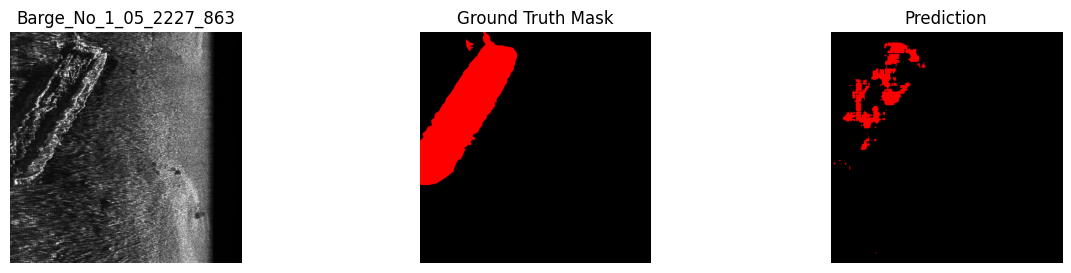

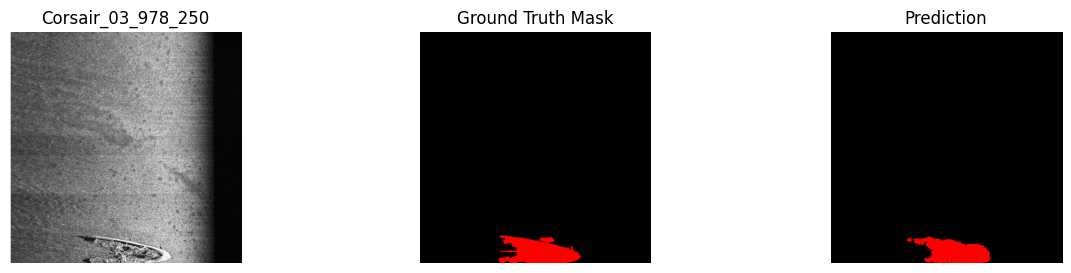

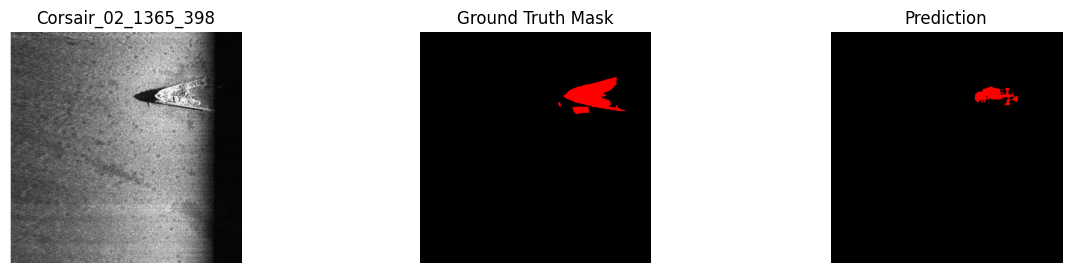

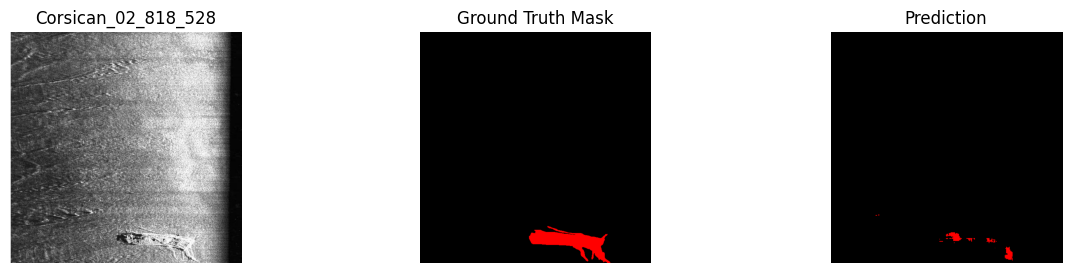

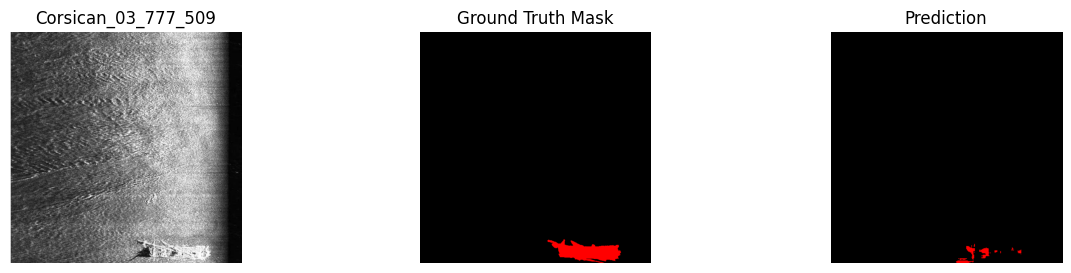

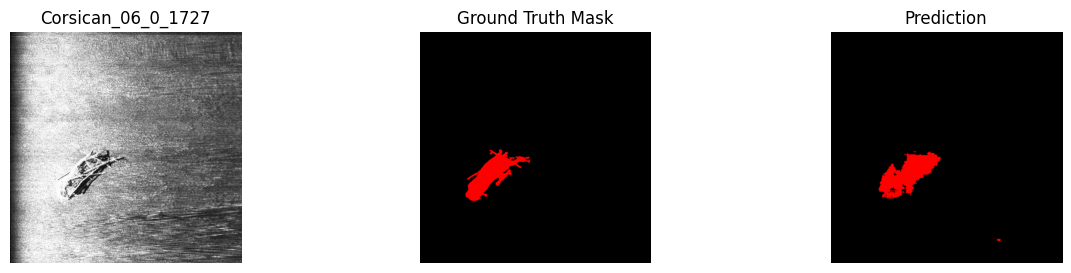

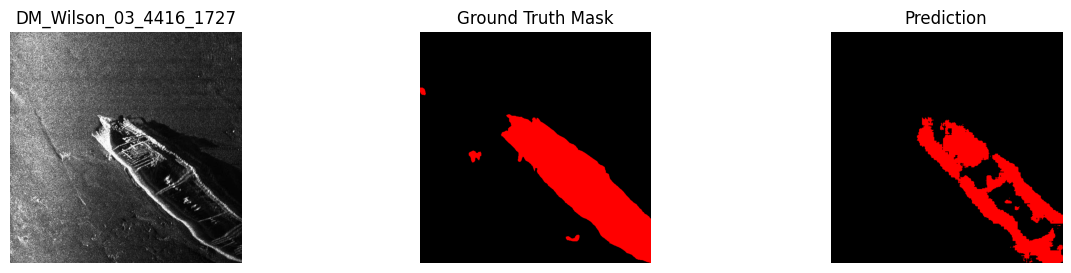

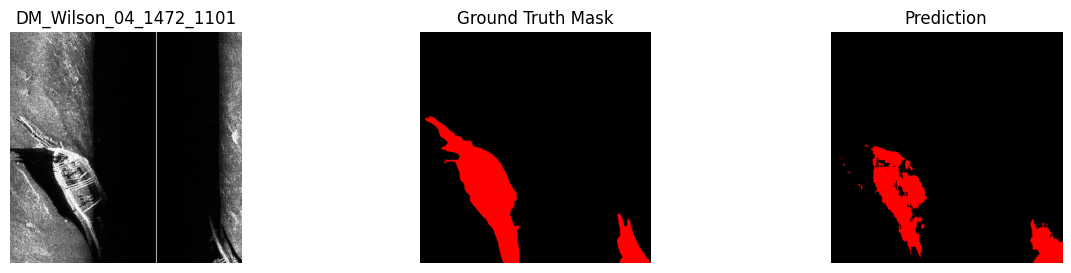

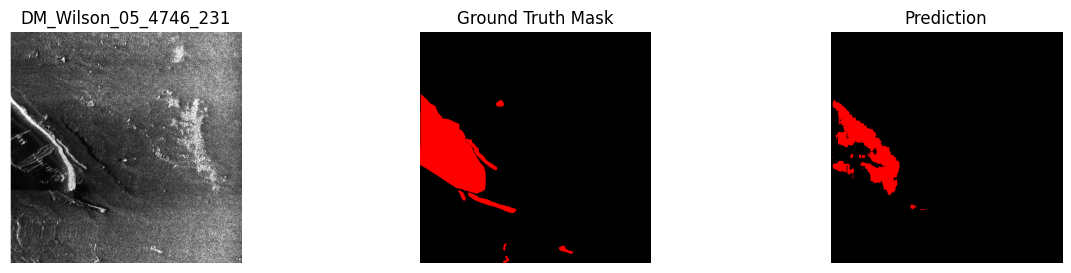

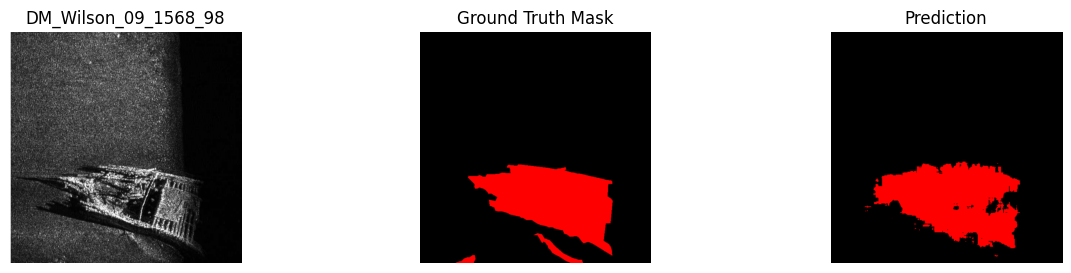

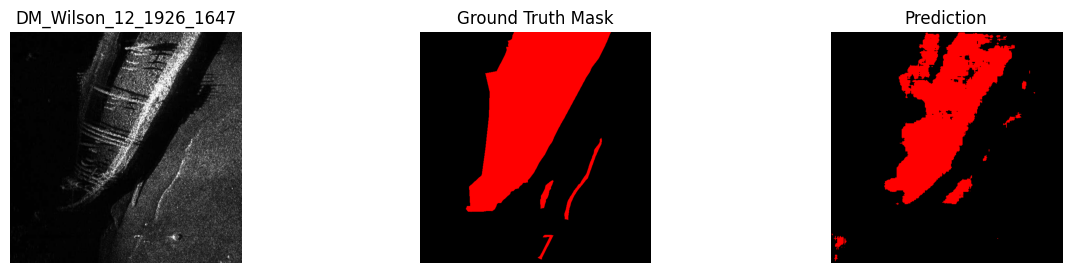

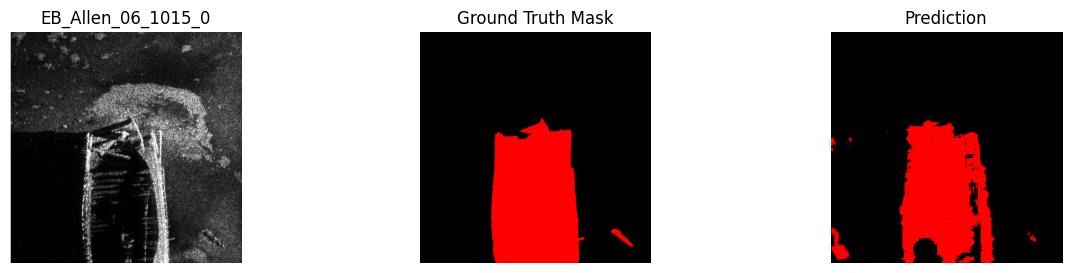

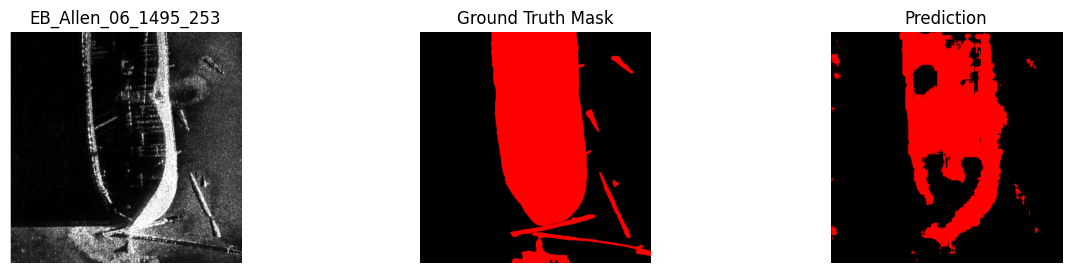

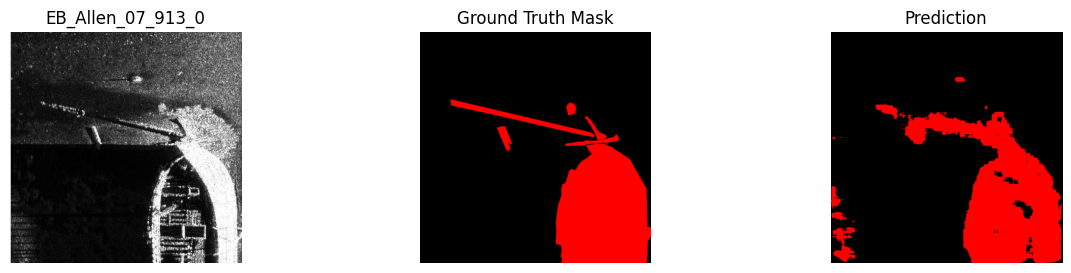

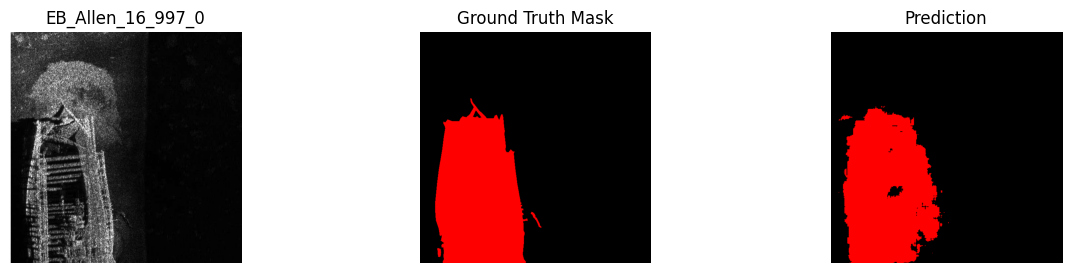

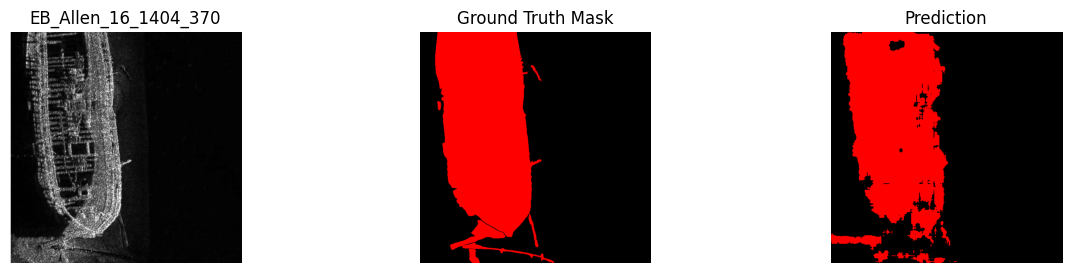

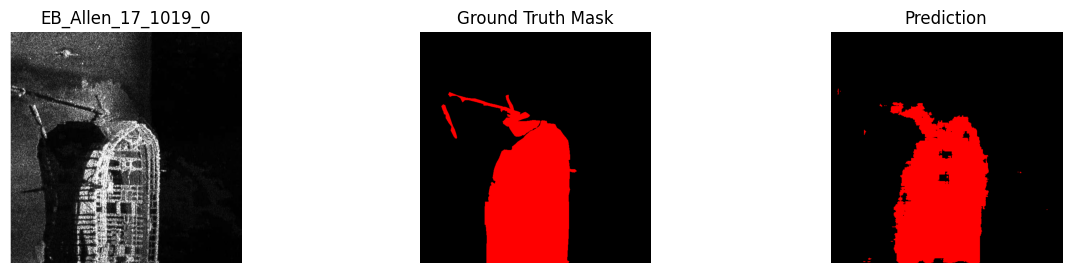

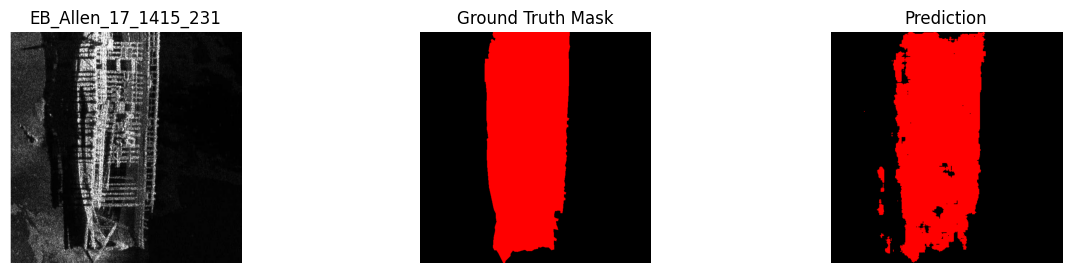

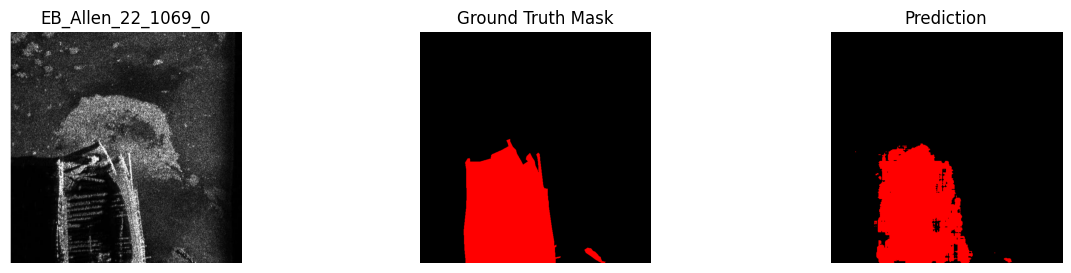

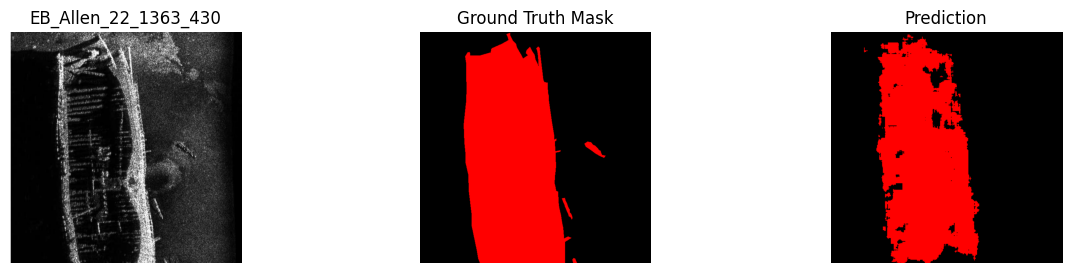

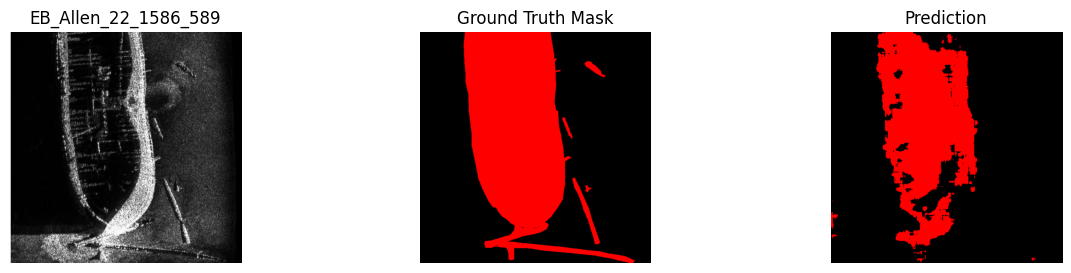

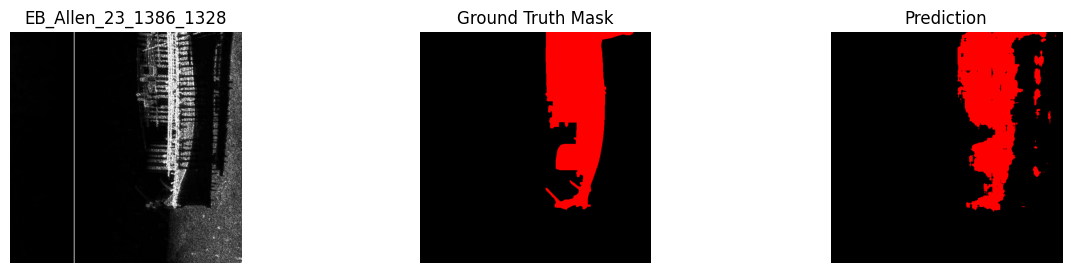

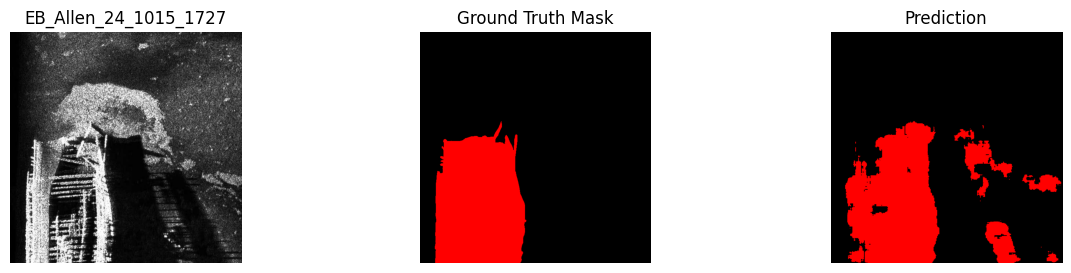

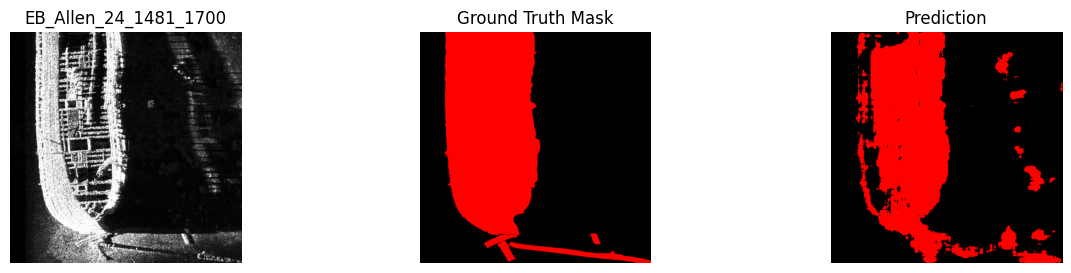

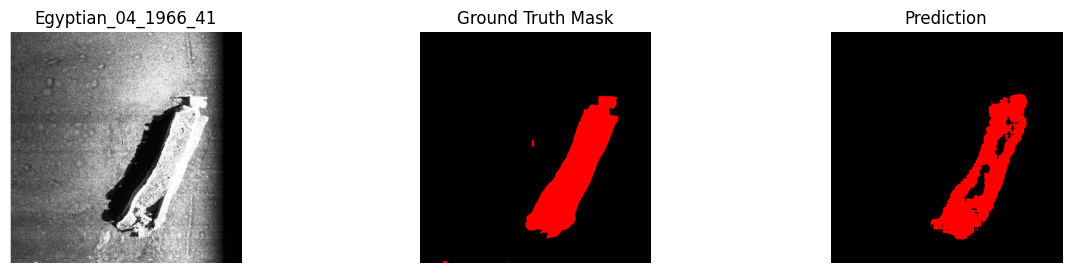

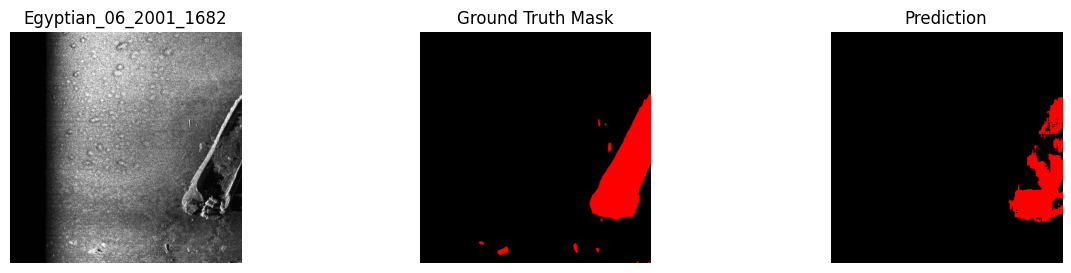

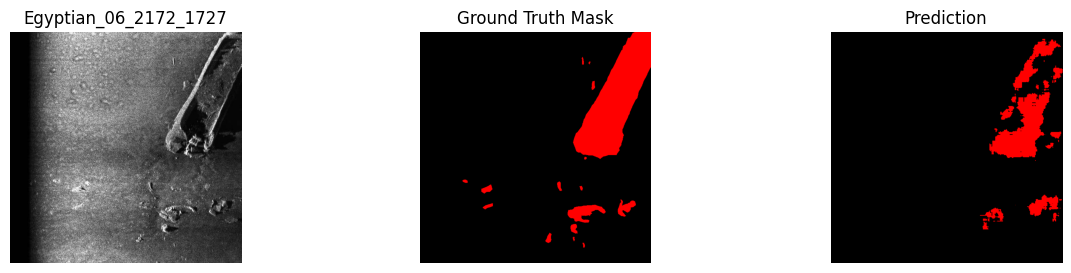

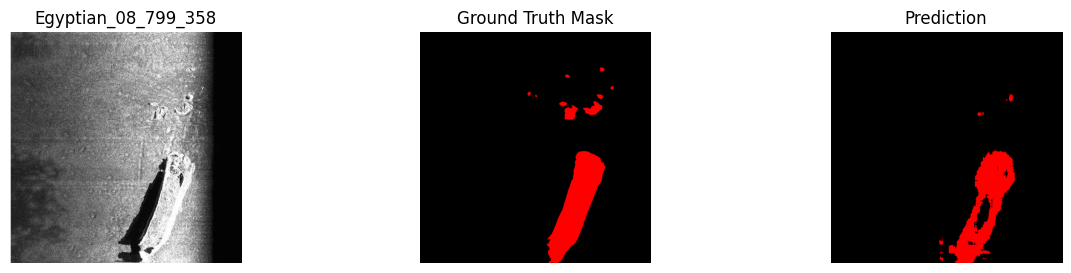

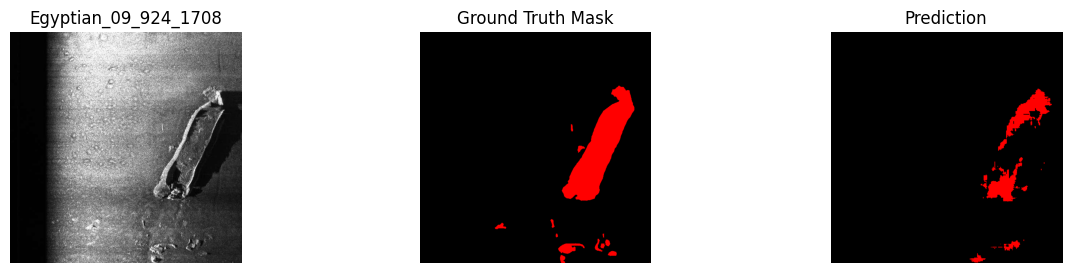

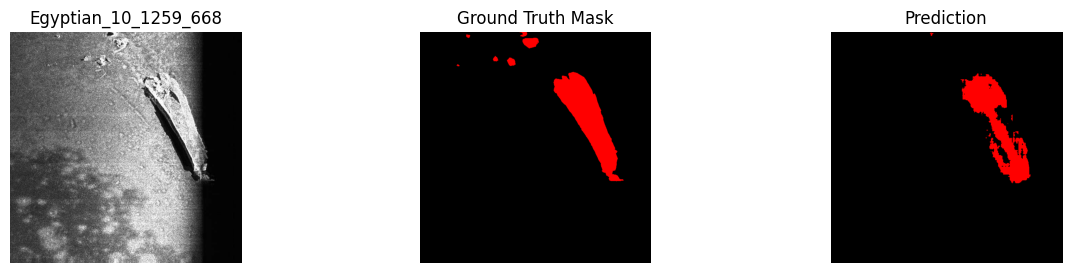

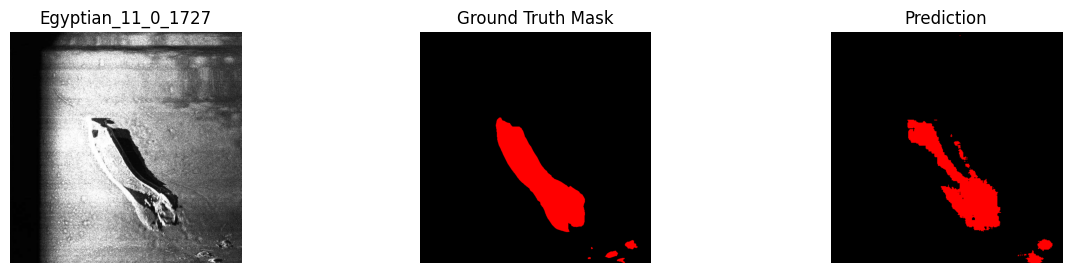

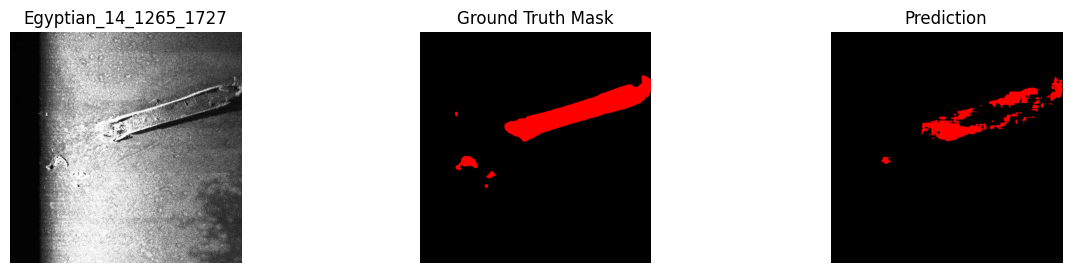

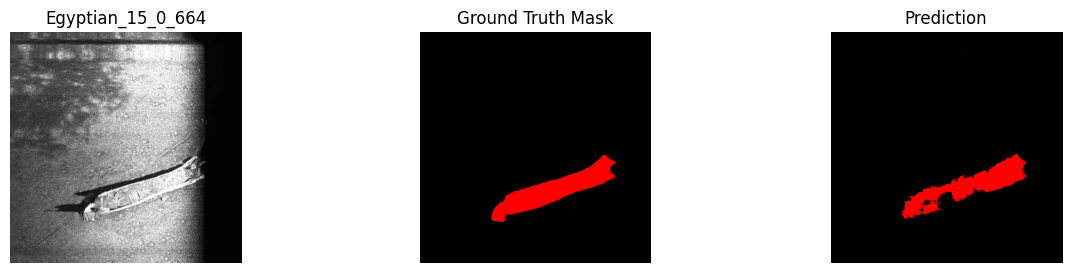

In [ ]:
loaded_model = UNetShipwreckDecoder().to(DEVICE)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

shipwrecks = [
    "Barge_No_1_05_2227_863",
    "Corsair_03_978_250",
    "Corsair_02_1365_398",
    "Corsican_02_818_528",
    "Corsican_03_777_509",
    "Corsican_06_0_1727",
    "DM_Wilson_03_4416_1727",
    "DM_Wilson_04_1472_1101",
    "DM_Wilson_05_4746_231",
    "DM_Wilson_09_1568_98",
    "DM_Wilson_12_1926_1647",
    "EB_Allen_06_1015_0",
    "EB_Allen_06_1495_253",
    "EB_Allen_07_913_0",
    "EB_Allen_16_997_0",
    "EB_Allen_16_1404_370",
    "EB_Allen_17_1019_0",
    "EB_Allen_17_1415_231",
    "EB_Allen_22_1069_0",
    "EB_Allen_22_1363_430",
    "EB_Allen_22_1586_589",
    "EB_Allen_23_1386_1328",
    "EB_Allen_24_1015_1727",
    "EB_Allen_24_1481_1700",
    "Egyptian_04_1966_41",
    "Egyptian_06_2001_1682",
    "Egyptian_06_2172_1727",
    "Egyptian_08_799_358",
    "Egyptian_09_924_1708",
    "Egyptian_10_1259_668",
    "Egyptian_11_0_1727",
    "Egyptian_14_1265_1727",
    "Egyptian_15_0_664",
]

colors = (np.array((0, 0, 0)), np.array((1, 0, 0)))
for file in shipwrecks:
    img_path = IMGS_PATH / (file + DATA_EXT)
    mask_path = MASK_PATH / (file + DATA_EXT)
    embed_path = EMBEDS_PATH / (file + '.npz')

    img = cv2.imread(str(img_path), cv2.IMREAD_COLOR_RGB)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED).astype(np.float32)
    with np.load(embed_path) as data:
        s1 = torch.from_numpy(data['stage3'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        s2 = torch.from_numpy(data['stage2'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        s3 = torch.from_numpy(data['stage1'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        s4 = torch.from_numpy(data['stage0'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    logits = model(s1, s2, s3, s4)
    probs = torch.sigmoid(logits)
    pred = (probs > 0.5).int().squeeze(0).squeeze(0).cpu().numpy()

    mask_rgb = np.zeros((mask.shape[0], mask.shape[1], 3))
    pred_rgb = np.zeros((mask.shape[0], mask.shape[0], 3))

    for label, color in zip((0.0, 1.0), colors):
        mask_rgb[mask == label] = color[:3]
        pred_rgb[pred == label] = color[:3]

    show_images(
        [(img, file), (mask_rgb, "Ground Truth Mask"), (pred_rgb, "Prediction")],
        num_images=3,
        normalize=False,
        cmap=None
    )